# Agent System Tests

Full end-to-end tests of the LangGraph agent graph.  
Uses a `MemorySaver` checkpointer so LangGraph manages state persistence.

Each test session is a **thread** (identified by `thread_id`). Calls on the same thread  
accumulate state; `graph.get_state()` lets you inspect what the agent stored.

**Prerequisites:**
- Rhino + Grasshopper running with the Swiftlet MCP server active (port 5001)
- `settings.py` + `.env.local` configured
- Run from the `src/` directory


In [52]:
## Setup — build graph with MemorySaver checkpointer
import os, sys, json, uuid, requests

# Ensure src/ is on the path
AGENT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if AGENT_ROOT not in sys.path:
    sys.path.insert(0, AGENT_ROOT)

from settings import LLM_PROVIDER, GEMINI_MODEL, MCP_GH_ENDPOINT
from langgraph.checkpoint.memory import MemorySaver
from graphs.main_graph import build_main_graph
from models.state import BoxState

memory = MemorySaver()
graph  = build_main_graph(checkpointer=memory)
print(f"Graph built ✓  (provider={LLM_PROVIDER}, model={GEMINI_MODEL})")

# Check MCP server (JSON-RPC 2.0 tools/list)
try:
    resp = requests.post(
        MCP_GH_ENDPOINT,
        json={"jsonrpc": "2.0", "id": 1, "method": "tools/list", "params": {}},
        headers={"Content-Type": "application/json"},
        timeout=3,
    )
    tools = resp.json().get("result", {}).get("tools", [])
    names = [t["name"] for t in tools]
    print(f"MCP Server : ✓  tools={names}")
except Exception as e:
    print(f"MCP Server : ✗  not reachable at {MCP_GH_ENDPOINT}  ({e})")

# ── Thread helpers ────────────────────────────────────────────────────────────
def new_thread(label: str = None) -> dict:
    tid = label or str(uuid.uuid4())[:8]
    print(f"thread_id : {tid}")
    return {"configurable": {"thread_id": tid}, "recursion_limit": 50}


def run(config: dict, user_input: str, request_type: str = None, **extra_request) -> tuple:
    req = {"user_input": user_input, **extra_request}
    result = graph.invoke(
        BoxState(request=req, request_type=request_type),
        config=config,
    )
    answer       = result.get("answer") or ""
    req_type     = result.get("request_type", "?")
    plan_results = result.get("plan_results") or {}

    print(f"\n{'═'*72}")
    print(f"  thread : {config['configurable']['thread_id']}  |  type : {req_type}")
    print(f"  input  : {user_input[:100]}{'…' if len(user_input) > 100 else ''}")
    print(f"{'─'*72}")
    if answer:
        print(answer)
    if plan_results:
        print(f"{'─'*72}")
        print("  plan_results:")
        for k, v in plan_results.items():
            print(f"    [{k}]  {str(v)[:150]}")
    print(f"{'═'*72}")
    return answer, result


def show_state(config: dict):
    snap = graph.get_state(config)
    if snap is None:
        print("No state — thread has not been used yet.")
        return None
    v = snap.values
    print(f"thread       : {config['configurable']['thread_id']}")
    print(f"request_type : {v.get('request_type')}")
    print(f"answer       : {str(v.get('answer') or '')[:120]}")
    print(f"plan_step    : {v.get('plan_step')}  /  plan_results: {list((v.get('plan_results') or {}).keys())}")
    return snap


Graph built ✓  (provider=gemini, model=gemini-2.5-flash-lite)
MCP Server : ✓  tools=['draw_box']


---
## 1 · MCP draw_box — direct JSON-RPC call

Test the Grasshopper MCP server directly (no LangGraph).  
Confirms Rhino is running and the `draw_box` tool responds correctly.


In [53]:
# ── 1a: list available MCP tools ─────────────────────────────────────────────
resp = requests.post(
    MCP_GH_ENDPOINT,
    json={"jsonrpc": "2.0", "id": 1, "method": "tools/list", "params": {}},
    headers={"Content-Type": "application/json"},
    timeout=5,
)
print(json.dumps(resp.json(), indent=2))


{
  "jsonrpc": "2.0",
  "id": 1,
  "result": {
    "tools": [
      {
        "name": "draw_box",
        "description": "draw_box",
        "inputSchema": {
          "type": "object",
          "properties": {
            "area": {
              "type": "number",
              "description": "area of the building"
            },
            "width": {
              "type": "number",
              "description": "width of the building"
            },
            "number_of_floors": {
              "type": "integer",
              "description": "building 's number of floors"
            },
            "floor_height": {
              "type": "number",
              "description": "floor height"
            }
          },
          "required": [
            "area",
            "width",
            "number_of_floors",
            "floor_height"
          ]
        }
      }
    ]
  }
}


In [54]:

# ── 1b: call draw_box and inspect the full response + output schema ───────────
resp = requests.post(
    MCP_GH_ENDPOINT,
    json={
        "jsonrpc": "2.0",
        "id": 2,
        "method": "tools/call",
        "params": {
            "name": "draw_box",
            "arguments": {
                "area": 150.0,
                "width": 10.0,
                "number_of_floors": 3,
                "floor_height": 4.0,
            },
        },
    },
    headers={"Content-Type": "application/json"},
    timeout=10,
)
data = resp.json()
print("── Full response ────────────────────────────────────────────────")
print(json.dumps(data, indent=2))

# ── Infer output schema from the returned content ────────────────────────────
import ast

content = data.get("result", {}).get("content", [])
print("\n── Inferred output schema ───────────────────────────────────────")
for item in content:
    if item.get("type") == "text":
        text = item["text"]
        try:
            parsed = json.loads(text)
        except json.JSONDecodeError:
            try:
                parsed = ast.literal_eval(text)
            except Exception:
                parsed = text
        if isinstance(parsed, dict):
            print(f"  type : object")
            for key, val in parsed.items():
                py_type = type(val).__name__ if val is not None else "null"
                print(f"    {key:<20} : {py_type}  (example: {val})")
        else:
            print(f"  type : {type(parsed).__name__}  value: {parsed}")


── Full response ────────────────────────────────────────────────
{
  "jsonrpc": "2.0",
  "id": 2,
  "result": {
    "content": [
      {
        "type": "text",
        "text": "{\r\n  \"width\": 10.0,\r\n  \"length\": 3.0,\r\n  \"height\": 4.0,\r\n  \"volume\": 14400.0\r\n}"
      }
    ]
  }
}

── Inferred output schema ───────────────────────────────────────
  type : object
    width                : float  (example: 10.0)
    length               : float  (example: 3.0)
    height               : float  (example: 4.0)
    volume               : float  (example: 14400.0)


---
## 2 · Building Design — ReAct + MCP draw_box via LangGraph

Forces `request_type="design_building"` so the graph runs:  
`retrieve_rules -> thinking -> execute_action -> draw_box (calls MCP) -> compliance_check -> is_compliant`

The agent iterates width until all rules pass, calling Grasshopper on every iteration.


In [55]:
# ── 2a: design a 1200 m² / 4-floor building 
design_a = new_thread("design-a")
answer_da, res_da = run(
    design_a,
    "Design a building that meets building code.",
    request_type="design_building",
    area=1200,
    n_floors=4,
    floor_height=3.5,
)

thread_id : design-a
  ┊ pre-set: design_building
  [draw_box] → MCP area=1200, width=10, height=14.0
  [draw_box] ← [{'type': 'text', 'text': '{\r\n  "width": 10.0,\r\n  "length": null,\r\n  "height": null,\r\n  "volume": null\r\n}'}]
  [draw_box] → MCP area=1200, width=25, height=14.0
  [draw_box] ← [{'type': 'text', 'text': '{\r\n  "width": 25.0,\r\n  "length": null,\r\n  "height": null,\r\n  "volume": null\r\n}'}]
  [draw_box] → MCP area=1200, width=25, height=14.0
  [draw_box] ← [{'type': 'text', 'text': '{\r\n  "width": 25.0,\r\n  "length": null,\r\n  "height": null,\r\n  "volume": null\r\n}'}]

════════════════════════════════════════════════════════════════════════
  thread : design-a  |  type : design_building
  input  : Design a building that meets building code.
────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════


In [56]:
# ── 2b: inspect final box + MCP results per iteration ────────────────────────
snap = graph.get_state(design_a)
v = snap.values

box = v.get("box") or {}
print("Final box:")
for k, val in box.items():
    print(f"  {k}: {val}")

print(f"\nCompliant   : {v.get('compliant')}")
print(f"Issues      : {v.get('issues')}")

print(f"\nReAct history ({len(v.get('history', []))} steps):")
for step in v.get("history", []):
    node = step.get("node", "?")
    if node == "draw_box":
        b = step.get("box", {})
        depth = b.get("depth")
        depth_str = f"{depth:.1f}" if depth is not None else "?"
        mcp = str(b.get("mcp_result", ""))[:60]
        print(f"  [draw_box]          width={b.get('width')}  depth={depth_str}  mcp={mcp}")
    elif node == "compliance_check":
        issues = step.get("issues", [])
        print(f"  [compliance_check]  issues={len(issues)}  {issues[:2]}")
    elif node == "is_compliant":
        print(f"  [is_compliant]      compliant={step.get('compliant')}")
    elif node == "action":
        print(f"  [action]            {step.get('action')}")


Final box:
  width: 25
  depth: 48.0
  area: 1200
  n_floors: 4
  floor_height: 3.5
  height: 14.0
  aspect_ratio: 0.5208333333333334
  emergency_exits: True
  window_area: None
  mcp_result: [{'type': 'text', 'text': '{\r\n  "width": 25.0,\r\n  "length": null,\r\n  "height": null,\r\n  "volume": null\r\n}'}]

Compliant   : True
Issues      : []

ReAct history (15 steps):
  [action]            {'action': 'adjust_width', 'params': {'width': 20}}
  [draw_box]          width=10  depth=120.0  mcp=[{'type': 'text', 'text': '{\r\n  "width": 10.0,\r\n  "lengt
  [compliance_check]  issues=3  ['Failed depth_constraint: Building depth must not exceed 50 meters for safety reasons', 'Failed ratio_constraint: Width to depth ratio must be at least 0.33 (1:3) for structural stability']
  [is_compliant]      compliant=False
  [action]            {'action': 'adjust_width', 'params': {'width': 25}}
  [draw_box]          width=25  depth=48.0  mcp=[{'type': 'text', 'text': '{\r\n  "width": 25.0,\r\n  "len

---
## 3 · Plan Execution

Forces `request_type="plan"` so the graph runs through  
`planner → execute_plan_step (loop) → plan_summary`.  
Each step's result is stored in `BoxState.plan_results` and persisted in the checkpointer.

In [57]:
# ── 3a: create two cylinders at different positions ───────────────────────────
plan_a = new_thread("plan-a")
answer_a, res_a = run(
    plan_a,
    "Use run_csharp_script to create a cylinder at origin with radius 3 and height 10. "
    "Then use run_csharp_script to create another cylinder at (20, 0, 0) with radius 2 and height 6. "
    "Return the GUID of each.",
    request_type="plan",
)
print("\nIndividual plan_results:")
for k, v in (res_a.get("plan_results") or {}).items():
    print(f"  {k}: {str(v)[:200]}")


thread_id : plan-a
  ┊ pre-set: plan

  ┊ synthesising plan summary...

════════════════════════════════════════════════════════════════════════
  thread : plan-a  |  type : plan
  input  : Use run_csharp_script to create a cylinder at origin with radius 3 and height 10. Then use run_cshar…
────────────────────────────────────────────────────────────────────────
Two cylinders were created:

*   **Cylinder 1:** Located at the origin (0, 0, 0) with a radius of 3 and a height of 10.
*   **Cylinder 2:** Located at (20, 0, 0) with a radius of 2 and a height of 6.
════════════════════════════════════════════════════════════════════════

Individual plan_results:


In [58]:
# ── 3b: create + move + capture viewport ─────────────────────────────────────
plan_b = new_thread("plan-b")
answer_b, res_b = run(
    plan_b,
    "1) Use run_csharp_script to create a box at origin (15×10×6) using Brep.CreateFromBox. "
    "2) Use run_csharp_script to move it 25 units along Y with Transform.Translation. "
    "3) Capture the viewport to show the result.",
    request_type="plan",
)
print("\nIndividual plan_results:")
for k, v in (res_b.get("plan_results") or {}).items():
    print(f"  {k}: {str(v)[:200]}")


thread_id : plan-b
  ┊ pre-set: plan

  ┊ synthesising plan summary...

════════════════════════════════════════════════════════════════════════
  thread : plan-b  |  type : plan
  input  : 1) Use run_csharp_script to create a box at origin (15×10×6) using Brep.CreateFromBox. 2) Use run_cs…
────────────────────────────────────────────────────────────────────────
A box with dimensions 15x10x6 was created at the origin and then moved 25 units along the Y-axis.
════════════════════════════════════════════════════════════════════════

Individual plan_results:


In [59]:
# ── Plan state inspection ─────────────────────────────────────────────────────
show_state(plan_b)

thread       : plan-b
request_type : plan
answer       : A box with dimensions 15x10x6 was created at the origin and then moved 25 units along the Y-axis.
plan_step    : 0  /  plan_results: []


StateSnapshot(values={'request': {'user_input': '1) Use run_csharp_script to create a box at origin (15×10×6) using Brep.CreateFromBox. 2) Use run_csharp_script to move it 25 units along Y with Transform.Translation. 3) Capture the viewport to show the result.'}, 'answer': 'A box with dimensions 15x10x6 was created at the origin and then moved 25 units along the Y-axis.', 'done': True, 'request_type': 'plan', 'search_results': [], 'plan_step': 0, 'plan_results': {}, 'messages': [], 'history': [{'node': 'plan_summary', 'answer': 'A box with dimensions 15x10x6 was created at the origin and then moved 25 units along the Y-axis.'}]}, next=(), config={'configurable': {'thread_id': 'plan-b', 'checkpoint_ns': '', 'checkpoint_id': '1f121f56-1230-6084-8004-875b056819fe'}}, metadata={'source': 'loop', 'writes': {'plan_summary': {'request': {'user_input': '1) Use run_csharp_script to create a box at origin (15×10×6) using Brep.CreateFromBox. 2) Use run_csharp_script to move it 25 units along Y wi

---
## 4 · Classifier — no forced `request_type`

Omit `request_type` so `classify_input` runs first.  
Verifies the LLM routes multi-step requests to `"plan"` automatically.

In [60]:

# ── Classification tests — calls classify_input_fn directly (no graph run) ───
import importlib, nodes.classification, io
from contextlib import redirect_stdout
importlib.reload(nodes.classification)
from nodes.classification import classify_input_fn

CLASSIFIER_TESTS = [
    ("design_building",   "Design a 5-floor office building with a total area of 2000 m² that meets the local building code requirements."),
    ("use_tool",          "Draw a cylinder at the origin with radius 5 and height 20."),
    ("show_guide",        "What are the design rules and constraints I need to follow for this project?"),
    ("general_question",  "What is the difference between a load-bearing wall and a curtain wall?"),
    ("plan",              "1) Create a box at origin (10×8×4) using run_csharp_script. 2) Move it 15 units along X. 3) Capture the viewport to confirm."),
    ("unknown",           "What is the best pizza topping for a Friday night?"),
]

results = {}
for expected, prompt in CLASSIFIER_TESTS:
    state = BoxState(request={"user_input": prompt})
    with redirect_stdout(io.StringIO()):          # suppress internal debug prints
        out = classify_input_fn(state)
    got = out.request_type
    ok = got == expected
    results[expected] = {"got": got, "ok": ok}
    mark = "PASS ✓" if ok else "FAIL ✗"
    print(f"  {mark}  expected={expected:<20}  got={got:<20}  └─ {prompt[:60]}{'…' if len(prompt)>60 else ''}")

print()
passed = sum(1 for r in results.values() if r["ok"])
print(f"  {passed}/{len(results)} passed")


  PASS ✓  expected=design_building       got=design_building       └─ Design a 5-floor office building with a total area of 2000 m…
  PASS ✓  expected=use_tool              got=use_tool              └─ Draw a cylinder at the origin with radius 5 and height 20.
  PASS ✓  expected=show_guide            got=show_guide            └─ What are the design rules and constraints I need to follow f…
  PASS ✓  expected=general_question      got=general_question      └─ What is the difference between a load-bearing wall and a cur…
  PASS ✓  expected=plan                  got=plan                  └─ 1) Create a box at origin (10×8×4) using run_csharp_script. …
  PASS ✓  expected=unknown               got=unknown               └─ What is the best pizza topping for a Friday night?

  6/6 passed


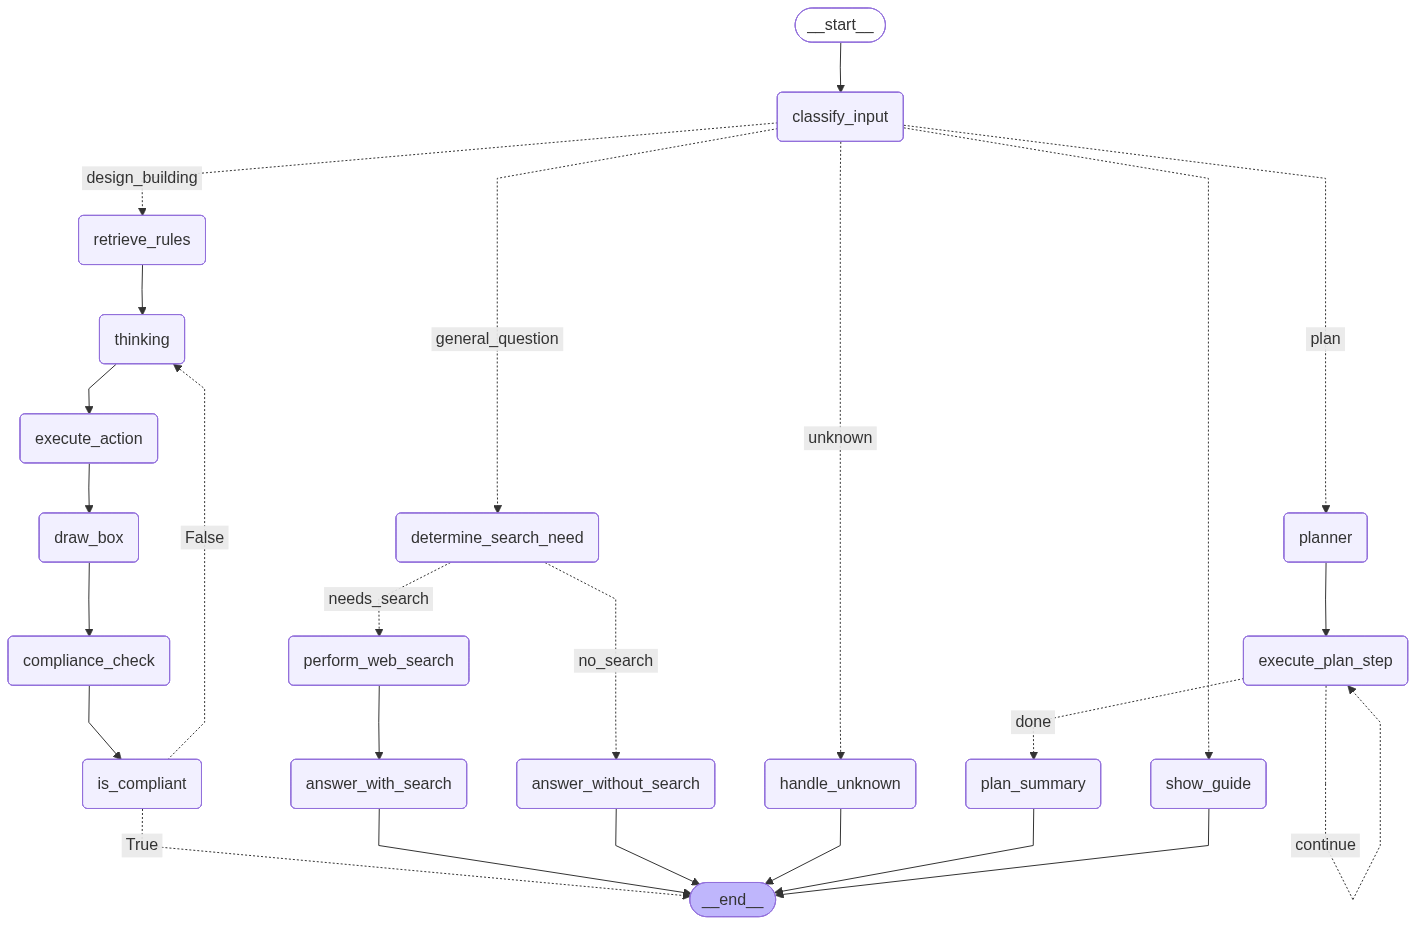

In [61]:

# ── Graph visualization ───────────────────────────────────────────────────────
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


---
## 5 · Full Agent Examples — one per classification

No `request_type` is forced in any cell below.  
The classifier runs first and routes to the correct branch automatically.

| Cell | Expected route       | Scenario                                    |
|------|----------------------|---------------------------------------------|
| 5a   | `design_building`    | Whole-building sizing with code compliance  |
| 5b   | `show_guide`         | Ask for design rules                        |
| 5c   | `general_question`   | Architecture knowledge Q&A                  |
| 5d   | `plan`               | Multi-step MCP tool chain                   |
| 5e   | `unknown`            | Off-topic request                           |

In [62]:
# ── 5a · design_building ──────────────────────────────────────────────────────
# Route: classify → retrieve_rules → thinking → execute_action
#        → draw_box (MCP) → compliance_check → is_compliant (loop)
agent_design = new_thread("5a-design")
answer_design, res_design = run(
    agent_design,
    "Design a building with 1200 m², 4 floors, and floor height 3.5 m "
    "that meets building code.",
    area=1200,
    n_floors=4,
    floor_height=3.5,
)

thread_id : 5a-design
  ┊ LLM raw: design_building
  ⇒ classified as: design_building

  [draw_box] → MCP area=1200, width=10, height=14.0
  [draw_box] ← [{'type': 'text', 'text': '{\r\n  "width": 10.0,\r\n  "length": null,\r\n  "height": null,\r\n  "volume": null\r\n}'}]
  [draw_box] → MCP area=1200, width=25, height=14.0
  [draw_box] ← [{'type': 'text', 'text': '{\r\n  "width": 25.0,\r\n  "length": null,\r\n  "height": null,\r\n  "volume": null\r\n}'}]
  [draw_box] → MCP area=1200, width=25, height=14.0
  [draw_box] ← [{'type': 'text', 'text': '{\r\n  "width": 25.0,\r\n  "length": null,\r\n  "height": null,\r\n  "volume": null\r\n}'}]

════════════════════════════════════════════════════════════════════════
  thread : 5a-design  |  type : design_building
  input  : Design a building with 1200 m², 4 floors, and floor height 3.5 m that meets building code.
────────────────────────────────────────────────────────────────────────
══════════════════════════════════════════════════════════

In [63]:
# ── 5b · show_guide ───────────────────────────────────────────────────────────
# Route: classify → show_guide → END
agent_guide = new_thread("5b-guide")
answer_guide, res_guide = run(
    agent_guide,
    "What are the design rules and constraints I need to follow for this project?",
)

thread_id : 5b-guide
  ┊ LLM raw: show_guide
  ⇒ classified as: show_guide


════════════════════════════════════════════════════════════════════════
  thread : 5b-guide  |  type : show_guide
  input  : What are the design rules and constraints I need to follow for this project?
────────────────────────────────────────────────────────────────────────
# Building Design Guidelines

- Maximum area is 3000 sqm (Max: 3000)
- Maximum building height is 18m (Max: 18)
- Maximum building width is 20m (Max: 20)
- Maximum building depth is 50m (Max: 50)
- Maximum number of floors is 4 (Max: 4)
- Minimum floor height is 2.7m (Min: 2.7)
- Maximum floor height is 5m (Max: 5)
- Width to depth ratio should be between 1:1 and 1:3 (Min: 0.3333333333333333, Max: 1)
- Minimum window area is 10% of floor area (Min: 0.1)
- Building must have emergency exits if floor area > 500 sqm (When: area > 500)

════════════════════════════════════════════════════════════════════════


In [64]:
# ── 5c-1 · general_question — NO search needed ───────────────────────────────
# Route: classify → determine_search_need → answer_WITHOUT_search → END
# Fundamental architectural concept — the LLM answers from its training knowledge.
agent_qa = new_thread("5c-no-search")
answer_qa, res_qa = run(
    agent_qa,
    "What is the difference between a load-bearing wall and a curtain wall?",
)
print(f"  needs_search : {res_qa.get('needs_search')}")

thread_id : 5c-no-search
  ┊ LLM raw: general_question
  ⇒ classified as: general_question

  ┊ search needed: False

════════════════════════════════════════════════════════════════════════
  thread : 5c-no-search  |  type : general_question
  input  : What is the difference between a load-bearing wall and a curtain wall?
────────────────────────────────────────────────────────────────────────
As an architectural assistant, I'm happy to clarify the fundamental differences between load-bearing walls and curtain walls. Understanding these distinctions is crucial for effective building design, as they dictate structural integrity, aesthetic possibilities, and functional performance.

### Load-Bearing Walls: The Structural Backbone

**Definition:** A load-bearing wall is a structural element that **supports and transfers vertical loads** from the floors, roof, and its own weight down to the foundation. In essence, it's a primary component of the building's structural system.

**Key Charac

In [65]:
# ── 5c-2 · general_question — search IS needed ─────────────────
# Route: classify → determine_search_need → answer_WITH_search → END
# Current-trends question — the LLM should recognise it needs a web search
# because it asks about recent/ongoing developments it may not know.
agent_qa2 = new_thread("5c-with-search")
answer_qa2, res_qa2 = run(
    agent_qa2,
    "What are the most prominent architecture and design trends emerging in 2025–2026, such as new materials, sustainable systems, or typological shifts?",
)
print(f"  needs_search : {res_qa2.get('needs_search')}")
sr = res_qa2.get('search_results') or []
print(f"  search hits  : {len(sr)}")

thread_id : 5c-with-search
  ┊ LLM raw: general_question
  ⇒ classified as: general_question

  ┊ search needed: True
  ┊ search query: 2025 2026 architecture design trends materials sustainability
                  typological shifts

════════════════════════════════════════════════════════════════════════
  thread : 5c-with-search  |  type : general_question
  input  : What are the most prominent architecture and design trends emerging in 2025–2026, such as new materi…
────────────────────────────────────────────────────────────────────────
The architecture and design landscape for 2025-2026 is characterized by a strong emphasis on **sustainability, technological integration, and human-centric design**. These trends are driven by a desire for healthier, more adaptive, and meaningful spaces, while also addressing urban expansion and evolving client expectations [Source 1, Source 3].

Here are some of the most prominent emerging trends:

**1. Deepening Commitment to Sustainability:**



In [74]:
# ── 5c-2 · general_question — search IS needed ────────────────────────────────
# Route: classify → determine_search_need → answer_WITH_search → END
# Current-trends question — the LLM should recognise it needs a web search
# because it asks about recent/ongoing developments it may not know.
agent_qa2 = new_thread("5c-with-search")
answer_qa2, res_qa2 = run(
    agent_qa2,
    "What are the most prominent architecture and design trends emerging in 2025–2026, "
    "such as new materials, sustainable systems, or typological shifts?",
)

# ── Search diagnostics ────────────────────────────────────────────────────────
needed = res_qa2.get("needs_search")
sr     = res_qa2.get("search_results") or []

if needed is None:
    status = "⚠  needs_search not set (node may not have run)"
elif needed:
    status = f"✓  search ran  ({len(sr)} result{'s' if len(sr) != 1 else ''})"
else:
    status = "–  search skipped (LLM decided not needed)"

print(f"\n  Search status : {status}")

if sr:
    print(f"  {'#':<3}  {'Title / URL':<55}  Snippet")
    print("  " + "─" * 90)
    for idx, hit in enumerate(sr, 1):
        title   = str(hit.get("title") or hit.get("url") or "—")[:53]
        snippet = str(hit.get("snippet") or hit.get("content") or "—").replace("\n", " ")[:60]
        print(f"  {idx:<3}  {title:<55}  {snippet}{'…' if len(snippet)==60 else ''}")
elif needed:
    print("  (no results returned — check search tool / API key)")


thread_id : 5c-with-search
  ┊ LLM raw: general_question
  ⇒ classified as: general_question

  ┊ search needed: True
  ┊ search query: 2025-2026 architecture design trends new materials sustainable
                  systems typological shifts

════════════════════════════════════════════════════════════════════════
  thread : 5c-with-search  |  type : general_question
  input  : What are the most prominent architecture and design trends emerging in 2025–2026, such as new materi…
────────────────────────────────────────────────────────────────────────
Based on the provided search results, here are the prominent architecture and design trends emerging for 2025-2026:

**Key Trends:**

*   **Deep Sustainability and Embodied Carbon Focus:** There's a significant shift in sustainability efforts, moving beyond just operational carbon (energy used during a building's life) to **embodied carbon** [Source 2]. This means architects are increasingly considering the emissions associated with the m

In [67]:
# ── 5e · unknown ──────────────────────────────────────────────────────────────
# Route: classify → handle_unknown → END
agent_unknown = new_thread("5e-unknown")
answer_unknown, res_unknown = run(
    agent_unknown,
    "What is the best pizza topping for a Friday night?",
)

thread_id : 5e-unknown
  ┊ LLM raw: general_question
  ⇒ classified as: general_question

  ┊ search needed: False

════════════════════════════════════════════════════════════════════════
  thread : 5e-unknown  |  type : general_question
  input  : What is the best pizza topping for a Friday night?
────────────────────────────────────────────────────────────────────────
While the question of the "best" pizza topping for a Friday night is subjective and falls outside the realm of architectural principles, I can offer a perspective that draws parallels to timeless design concepts and established practices in building. Think of your pizza as a building, and the toppings as its functional and aesthetic elements.

When considering the "best" pizza topping, we can look at it through the lens of **durability, balance, and user experience**, much like we would when designing a structure.

**1. Foundation and Structural Integrity (The Base and Sauce):**
Just as a building needs a strong founda

In [68]:
# ── 5f · summary ──────────────────────────────────────────────────────────────
sessions = [
    ("design_building",  res_design),
    ("show_guide",       res_guide),
    ("general_question", res_qa),
    ("plan",             res_plan),
    ("unknown",          res_unknown),
]
print(f"  {'Expected':<20}  {'Got':<20}  Answer preview")
print("  " + "─" * 70)
for label, r in sessions:
    got  = r.get("request_type", "?")
    ans  = str(r.get("answer") or "").replace("\n", " ")[:50]
    mark = "✓" if got == label else f"✗ got '{got}'"
    print(f"  {label:<20}  {mark:<20}  {ans}{'…' if len(ans) == 50 else ''}")

  Expected              Got                   Answer preview
  ──────────────────────────────────────────────────────────────────────
  design_building       ✓                     
  show_guide            ✓                     # Building Design Guidelines  - Maximum area is 30…
  general_question      ✓                     As an architectural assistant, I'm happy to clarif…
  plan                  ✗ got 'use_tool'       I'm not sure how to process your request: "1) Use…
  unknown               ✗ got 'general_question'  While the question of the "best" pizza topping for…


---
## 6 · State History

`graph.get_state_history(config)` returns every checkpoint saved for a thread —  
useful for debugging node flow and seeing where the graph branched.  
Set `target` in the cell above to whichever agent run you want to inspect.


In [69]:
target = agent_plan  # change to agent_design, agent_guide, agent_qa, agent_unknown


In [70]:
# ── State history for a thread ────────────────────────────────────────────────

print(f"State history for thread '{target['configurable']['thread_id']}' (most recent first):")
for i, snap in enumerate(graph.get_state_history(target)):
    v = snap.values
    print(
        f"  [{i:2d}] next={str(snap.next):30s}  "
        f"req_type={str(v.get('request_type')):18s}  "
        f"msgs={len(v.get('messages', []))}  "
        f"plan_step={v.get('plan_step')}"
    )
    if i >= 15:
        print("  … (truncated — adjust limit to see more)")
        break

State history for thread '5d-plan' (most recent first):
  [ 0] next=()                              req_type=use_tool            msgs=0  plan_step=0
  [ 1] next=('handle_unknown',)             req_type=use_tool            msgs=0  plan_step=0
  [ 2] next=('classify_input',)             req_type=None                msgs=0  plan_step=0
  [ 3] next=('__start__',)                  req_type=None                msgs=0  plan_step=None


---
### 6b · Multi-turn Memory — continue from an existing session

`MemorySaver` persists the full `BoxState` checkpoint for every thread.  
Sending a **new message to the same `thread_id`** lets the agent pick up  
exactly where it left off — the `messages` list (reducer: `operator.add`)  
accumulates across turns, so the LLM sees the full conversation history.

**Demo**: reuse `agent_design` (1200 m², 4 floors, 3.5 m) from §5a  
and ask the agent to revise the building — *without* repeating any numbers.

In [71]:
# ── 6b-1 · Inspect state before the follow-up ────────────────────────────────
# Shows what the agent already "knows" from the §5a run on this thread.
snap_before = show_state(agent_design)
print()
msgs = (snap_before.values.get("messages") or []) if snap_before else []
print(f"Messages stored in memory : {len(msgs)}")
for m in msgs[-4:]:          # print last 4 to keep output tidy
    role    = m.get("role", "?")
    preview = str(m.get("content", ""))[:120].replace("\n", " ")
    print(f"  [{role:9s}]  {preview}{'...' if len(str(m.get('content',''))) > 120 else ''}")

thread       : 5a-design
request_type : design_building
answer       : 
plan_step    : 0  /  plan_results: []

Messages stored in memory : 0


In [72]:
# ── 6b-2 · Follow-up task — agent uses memory of the existing building ────────
# No area / n_floors / floor_height supplied — the agent must recall them
# from the checkpoint messages stored in MemorySaver.
answer_followup, res_followup = run(
    agent_design,                               # ← same thread as § 5a
    "I want to add 2 more floors to the building you just designed. "
    "Keep the same area and floor height as before, and re-check compliance.",
)

  ┊ LLM raw: design_building
  ⇒ classified as: design_building

  [draw_box] → MCP area=800, width=29, height=14.0
  [draw_box] ← [{'type': 'text', 'text': '{\r\n  "width": 29.0,\r\n  "length": null,\r\n  "height": null,\r\n  "volume": null\r\n}'}]

════════════════════════════════════════════════════════════════════════
  thread : 5a-design  |  type : design_building
  input  : I want to add 2 more floors to the building you just designed. Keep the same area and floor height a…
────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════


In [73]:
# ── 6b-3 · Compare state before vs after the follow-up ───────────────────────
snap_after = show_state(agent_design)
print()
box_after = (snap_after.values.get("box") or {}) if snap_after else {}
msgs_after = (snap_after.values.get("messages") or []) if snap_after else []
print(f"Messages in memory now     : {len(msgs_after)}  (was {len(msgs)})")
print(f"Updated box params         : {box_after}")

thread       : 5a-design
request_type : design_building
answer       : 
plan_step    : 0  /  plan_results: []

Messages in memory now     : 0  (was 0)
Updated box params         : {'width': 29, 'depth': 27.586206896551722, 'area': 800, 'n_floors': 4, 'floor_height': 3.5, 'height': 14.0, 'aspect_ratio': 1.05125, 'emergency_exits': True, 'window_area': None, 'mcp_result': '[{\'type\': \'text\', \'text\': \'{\\r\\n  "width": 29.0,\\r\\n  "length": null,\\r\\n  "height": null,\\r\\n  "volume": null\\r\\n}\'}]'}
